In [ ]:
#I had to install these
#pip install pyspark==3.5.3 matplotlib seaborn

## Top 5 methods of Anomaly Detection

### Data set up

In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("Seattle911").getOrCreate()


file_path = "/Users/maggiekettle/Desktop/6242 Project/call_data_20251019_processed_v3.csv" #need to change this to a different path
df_spark = spark.read.csv(file_path, header=True, inferSchema=True)

print(df_spark.columns)
print(df_spark.count())

25/10/26 17:54:50 WARN Utils: Your hostname, Maggies-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 10.0.0.179 instead (on interface en0)
25/10/26 17:54:50 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/26 17:54:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


['cad_event_number', 'cad_event_clearance_description', 'call_type', 'priority', 'initial_call_type', 'initial_call_type_priority_mapping', 'initial_call_type_mapping', 'final_call_type', 'final_call_type_mapping', 'cad_event_original_time_queued', 'cad_event_original_time_queued_date', 'cad_event_original_time_queued_time', 'cad_event_original_time_queued_datetime', 'cad_event_original_time_queued_datetime_hour', 'cad_event_arrived_time_datetime', 'dispatch_precinct', 'dispatch_sector', 'dispatch_beat', 'dispatch_longitude', 'dispatch_latitude', 'dispatch_reporting_area', 'cad_event_response_category', 'call_sign_dispatch_id', 'call_sign_dispatch_time_datetime', 'first_care_call_sign_at_scene_time_datetime', 'first_care_call_sign_dispatch_time_datetime', 'first_co_response_call_sign_at_scene_time_datetime', 'first_co_response_call_sign_dispatch_time_datetime', 'first_spd_call_sign_at_scene_time_datetime', 'first_spd_call_sign_dispatch_time_datetime', 'last_care_call_sign_in_service_ti

641904


In [ ]:
from pyspark.sql import functions as F

df_spark = df_spark.withColumn("event_time", F.to_timestamp("cad_event_original_time_queued", "MM/dd/yyyy hh:mm:ss a"))

df_spark = df_spark.withColumn("date", F.to_date("event_time"))
df_spark = df_spark.withColumn("hour", F.hour("event_time"))

df_spark.select("cad_event_original_time_queued", "event_time", "date", "hour", "call_type", "call_sign_total_service_time_s").show(10, truncate=False)


+------------------------------+-------------------+----------+----+-----------------------+------------------------------+
|cad_event_original_time_queued|event_time         |date      |hour|call_type              |call_sign_total_service_time_s|
+------------------------------+-------------------+----------+----+-----------------------+------------------------------+
|11/06/2023 09:07:20 AM        |2023-11-06 09:07:20|2023-11-06|9   |911                    |28                            |
|11/06/2023 09:08:06 AM        |2023-11-06 09:08:06|2023-11-06|9   |TELEPHONE OTHER NOT 911|2982                          |
|11/06/2023 09:08:22 AM        |2023-11-06 09:08:22|2023-11-06|9   |911                    |113                           |
|11/06/2023 09:08:54 AM        |2023-11-06 09:08:54|2023-11-06|9   |911                    |2872                          |
|11/06/2023 09:09:46 AM        |2023-11-06 09:09:46|2023-11-06|9   |911                    |5334                          |
|11/06/2

In [3]:
#AGGREGATE DATA OVER TIME --- DO HOUR OR DAY
# and compute average service time for each group
#daily_calls = (df_spark.groupBy("date", "Call Type")
#    .agg(F.count("*").alias("total_calls"),F.avg("Call Sign Total Service Time (s)").alias("avg_service_time"))
#    .orderBy("date"))
#daily_calls.show(10, truncate=False)

hourly_calls = (df_spark.groupBy("date", "hour", "call_type").agg( F.count("*").alias("total_calls"), 
                        F.avg("call_sign_total_service_time_s").alias("avg_service_time")).orderBy("date", "hour"))
hourly_calls.show(10)

+----------+----+--------------------+-----------+------------------+
|      date|hour|           call_type|total_calls|  avg_service_time|
+----------+----+--------------------+-----------+------------------+
|2023-10-27|   0|TELEPHONE OTHER N...|          3|2892.3333333333335|
|2023-10-27|   0|                 911|         17| 4503.235294117647|
|2023-10-27|   0|ALARM CALL (NOT P...|          3|1166.6666666666667|
|2023-10-27|   0|              ONVIEW|          6| 6413.333333333333|
|2023-10-27|   1|              ONVIEW|          4|           5705.25|
|2023-10-27|   1|                 911|         14|3577.8571428571427|
|2023-10-27|   1|ALARM CALL (NOT P...|          3|            2300.0|
|2023-10-27|   1|TELEPHONE OTHER N...|          5|            3917.8|
|2023-10-27|   2|TELEPHONE OTHER N...|          2|            1177.5|
|2023-10-27|   2|                 911|          4|            761.75|
+----------+----+--------------------+-----------+------------------+
only showing top 10 

### Response Time Anomalies by Call Type + Time of Day

Detect unusually long or short response times relative to expected norms for that type of call, time of day, and dispatch area.

Use isolation forest to find above 99th or below 1st percnetile

In [5]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

#Maybe make a rolling z-score over time for finer detection?
window = Window.partitionBy("call_type")

hourly_calls = (hourly_calls.withColumn("mean_calls", F.avg("total_calls").over(window))
                .withColumn("std_calls", F.stddev("total_calls").over(window)))

hourly_calls = hourly_calls.withColumn("z_score",(F.col("total_calls") - F.col("mean_calls")) / (F.col("std_calls") + F.lit(1e-6)))

hourly_calls = hourly_calls.withColumn("is_anomaly", (F.abs(F.col("z_score")) > 2.5).cast("int"))

hourly_calls.select( "date", "hour", "call_type", "total_calls", "mean_calls", "std_calls", "z_score", "is_anomaly")\
                        .orderBy("date", "hour").show(20, truncate=False)


+----------+----+-----------------------------+-----------+------------------+------------------+--------------------+----------+
|date      |hour|call_type                    |total_calls|mean_calls        |std_calls         |z_score             |is_anomaly|
+----------+----+-----------------------------+-----------+------------------+------------------+--------------------+----------+
|2023-10-27|0   |ALARM CALL (NOT POLICE ALARM)|3          |1.9               |1.2074621139733765|0.9110009136264631  |0         |
|2023-10-27|0   |911                          |17         |17.75854478044259 |7.262480251987916 |-0.10444705523129015|0         |
|2023-10-27|0   |ONVIEW                       |6          |10.379653628652214|6.971408608667513 |-0.6282307129403236 |0         |
|2023-10-27|0   |TELEPHONE OTHER NOT 911      |3          |8.34330283837673  |4.837105527919149 |-1.1046485760724685 |0         |
|2023-10-27|1   |911                          |14         |17.75854478044259 |7.2624802519

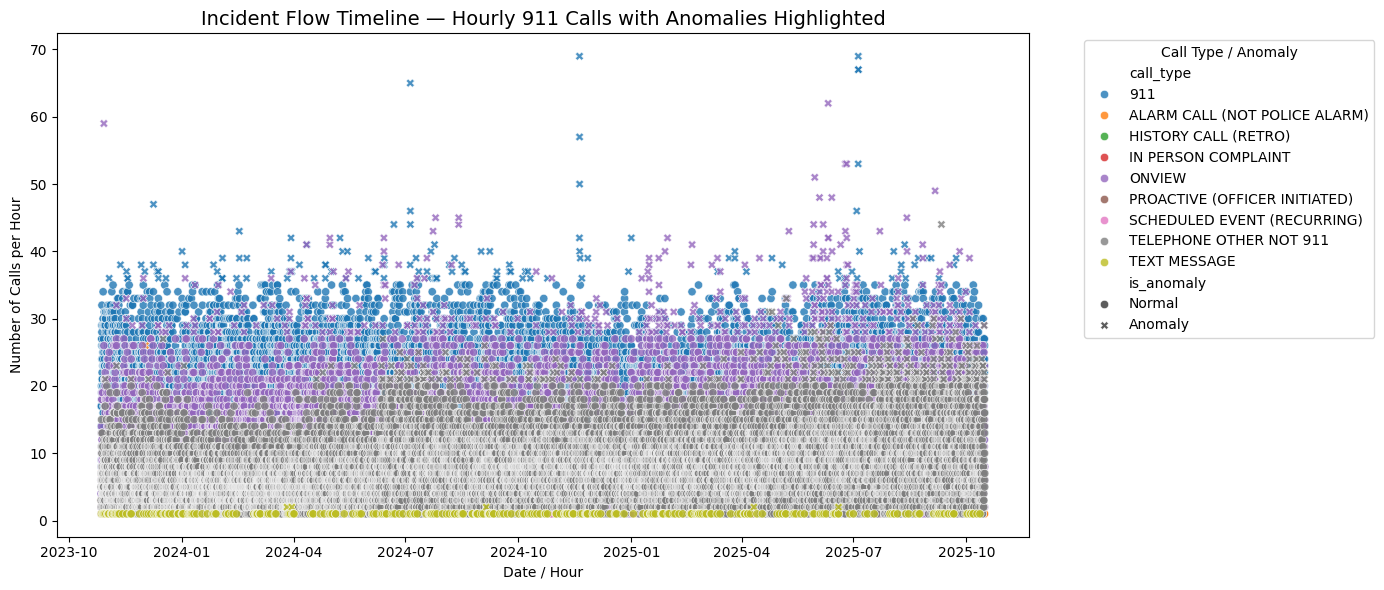

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

hourly_calls_pd = hourly_calls.toPandas()
hourly_calls_pd["datetime"] = pd.to_datetime(hourly_calls_pd["date"]) + pd.to_timedelta(hourly_calls_pd["hour"], unit="h")

plt.figure(figsize=(14, 6))

sns.scatterplot(data=hourly_calls_pd, x="datetime", y="total_calls", hue="call_type", style=hourly_calls_pd["is_anomaly"].map({1: "Anomaly", 0: "Normal"}), palette="tab10", alpha=0.8)

plt.title("Incident Flow Timeline — Hourly 911 Calls with Anomalies Highlighted", fontsize=14)
plt.xlabel("Date / Hour")
plt.ylabel("Number of Calls per Hour")
plt.legend(title="Call Type / Anomaly", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Most hours show consistent 911 activity, with call volumes typically ranging between 10–35 per hour across all types. The majority of points fall within this normal range, indicating stable response patterns over time. A few clear spikes stand out — moments where calls per hour jump above 60 — suggesting unusual bursts in activity likely tied to large incidents or surges in demand. These anomalies mainly occur in the higher-volume call types like 911 and ONVIEW, while low-volume types remain steady, pointing to system-wide reliability with occasional high-stress periods worth investigating further.

In [7]:
hourly_calls_w_cad = (df_spark.select("cad_event_number", "date", "hour", "call_type", "call_sign_total_service_time_s").join(hourly_calls, on=["date", "hour", "call_type"], how="left"))
hourly_calls_w_cad.select("cad_event_number", "date", "hour", "call_type","total_calls", "avg_service_time", "is_anomaly").show(10, truncate=False)

+----------------+----------+----+-----------------------+-----------+------------------+----------+
|cad_event_number|date      |hour|call_type              |total_calls|avg_service_time  |is_anomaly|
+----------------+----------+----+-----------------------+-----------+------------------+----------+
|2023000321297   |2023-11-06|9   |TELEPHONE OTHER NOT 911|13         |5194.692307692308 |0         |
|2023000321301   |2023-11-06|9   |TELEPHONE OTHER NOT 911|13         |5194.692307692308 |0         |
|2023000321306   |2023-11-06|9   |TELEPHONE OTHER NOT 911|13         |5194.692307692308 |0         |
|2023000321303   |2023-11-06|9   |ONVIEW                 |11         |2246.7272727272725|0         |
|2023000321305   |2023-11-06|9   |ONVIEW                 |11         |2246.7272727272725|0         |
|2023000321296   |2023-11-06|9   |911                    |26         |3096.6153846153848|0         |
|2023000321298   |2023-11-06|9   |911                    |26         |3096.6153846153848|0 

### Call Type Mismatch Anomalies (Initial vs Final)

Find cases where the initial classification differs significantly from the final (e.g., “Aid Response” → “Structure Fire”).

Build a confusion matrix or frequency table of transitions; use rare transitions as anomalies.

In [15]:
#set up 
from pyspark.sql import functions as F
INITIAL_COL = "initial_call_type_mapping"
FINAL_COL = "final_call_type_mapping"
df_spark.select(INITIAL_COL, FINAL_COL).show(5)

+-------------------------+-----------------------+
|initial_call_type_mapping|final_call_type_mapping|
+-------------------------+-----------------------+
|     DISTURBANCE - DV ...|             SUSPICIOUS|
|                      TRU|                   BURG|
|                      OBS|    DISTURBANCE - OTHER|
|                 PROPERTY|             SUSPICIOUS|
|                     AUTO|                   AUTO|
+-------------------------+-----------------------+
only showing top 5 rows



In [9]:
transition_counts = (df_spark.groupBy(INITIAL_COL, FINAL_COL).agg(F.count("*").alias("count")).orderBy(F.desc("count")))
transition_counts.show(20, truncate=False)

+-------------------------------------------+---------------------------------+-----+
|initial_call_type_mapping                  |final_call_type_mapping          |count|
+-------------------------------------------+---------------------------------+-----+
|SUSPICIOUS                                 |SUSPICIOUS                       |35825|
|TRAF                                       |TRAF                             |30362|
|PARKING VIOLATION (EXCEPT ABANDONED CAR)   |TRAF                             |26483|
|DISTURBANCE                                |DISTURBANCE - OTHER              |20119|
|AUTO                                       |AUTO                             |18031|
|ASSIST                                     |ASSIST                           |17267|
|PREMISE CHECK OFFICER INITIATED ONVIEW ONLY|PREMISE CHECKS - CRIME PREVENTION|17133|
|DIRECTED PATROL ACTIVITY                   |DIRECTED PATROL ACTIVITY         |15984|
|TRESPASS                                   |PROWLER -

In [10]:
total_calls = df_spark.count()

transition_counts = transition_counts.withColumn("pct", F.col("count") / F.lit(total_calls))
transition_counts = transition_counts.withColumn("is_anomaly",(F.col("pct") < 0.005).cast("int"))
transition_counts.orderBy("pct").show(20, truncate=False)

+----------------------------------------+---------------------------------------+-----+---------------------+----------+
|initial_call_type_mapping               |final_call_type_mapping                |count|pct                  |is_anomaly|
+----------------------------------------+---------------------------------------+-----+---------------------+----------+
|HAZ - CRITICAL                          |CRISIS COMPLAINT - PICK-UP OR TRANSPORT|1    |1.5578653505820184E-6|1         |
|BURG                                    |KIDNAP - GENERAL                       |1    |1.5578653505820184E-6|1         |
|FRAUD                                   |VICE - PORNOGRAPHY                     |1    |1.5578653505820184E-6|1         |
|ASSIST                                  |PRISONER ESCORT - BUSY CODE            |1    |1.5578653505820184E-6|1         |
|SHOT                                    |AUTO                                   |1    |1.5578653505820184E-6|1         |
|ABDUCTION - CRITICAL   

In [11]:
transition_counts = transition_counts.withColumn("is_self_transition", (F.col(INITIAL_COL) == F.col(FINAL_COL)).cast("int"))

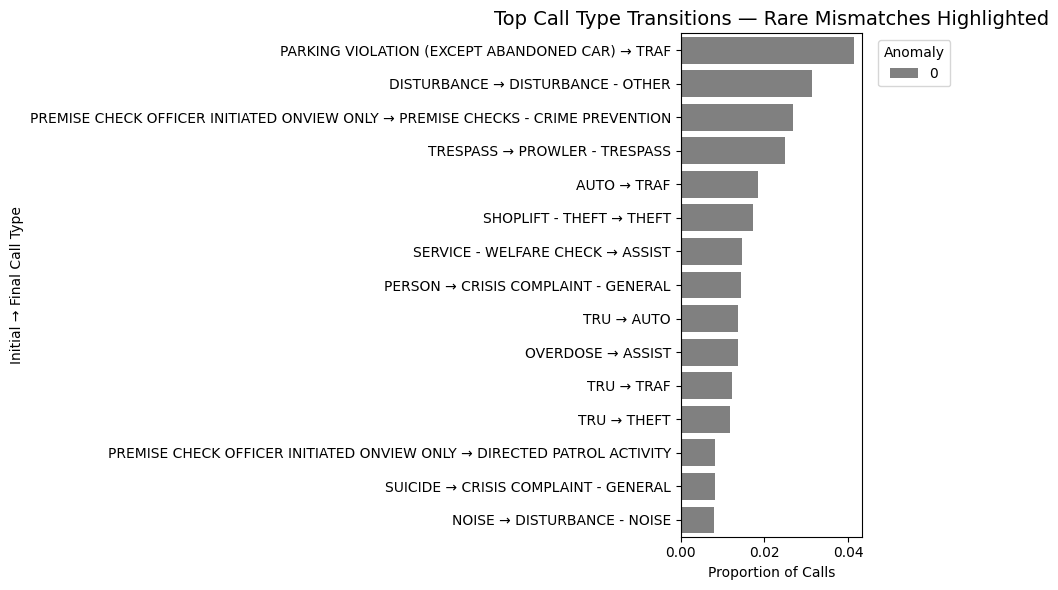

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

transition_pd = transition_counts.toPandas()
if "is_self_transition" in transition_pd.columns:
    transition_pd = transition_pd[transition_pd["is_self_transition"] == 0]
transition_pd["transition_label"] = transition_pd[INITIAL_COL] + " → " + transition_pd[FINAL_COL]
top_transitions = transition_pd.sort_values("pct", ascending=False).head(15)


plt.figure(figsize=(10, 6))
sns.barplot(data=top_transitions, x="pct", y="transition_label", hue="is_anomaly", dodge=False, palette={0: "gray", 1: "red"})
plt.title("Top Call Type Transitions — Rare Mismatches Highlighted", fontsize=14)
plt.xlabel("Proportion of Calls")
plt.ylabel("Initial → Final Call Type")
plt.legend(title="Anomaly", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Text(0.5, 1.0, 'Rare Call Type Mismatches (<0.5% Frequency)')

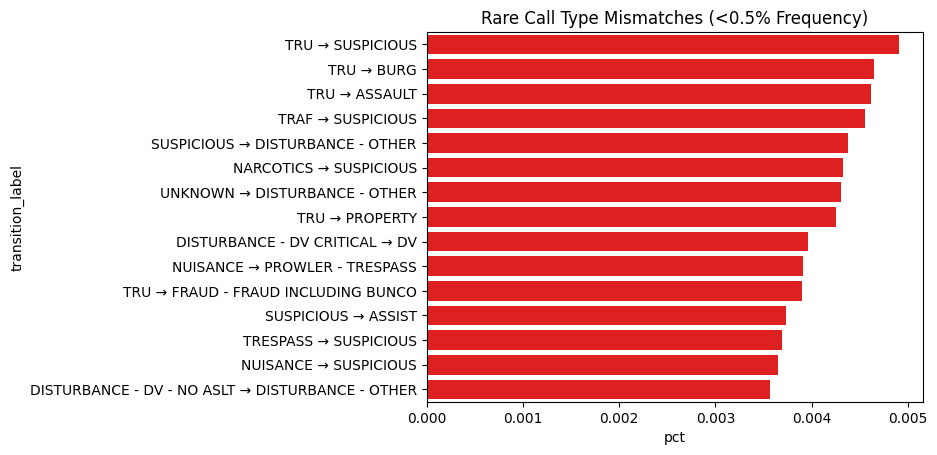

In [13]:
rare_transitions = transition_pd[transition_pd["is_anomaly"] == 1]
sns.barplot(
    data=rare_transitions.sort_values("pct", ascending=False).head(15),
    x="pct", y="transition_label", color="red"
)
plt.title("Rare Call Type Mismatches (<0.5% Frequency)")


Most of the common transitions make sense and are just different ways of labeling the same kind of call — like small naming tweaks rather than real mismatches.
In the rare group (<0.5%), almost everything is still just wording differences, but there are a few (around four or five) that look like real anomalies where the type of situation actually changed once responders got there.

In [17]:
CAD_COL = "cad_event_number"

transition_w_cad = (df_spark.select(CAD_COL, INITIAL_COL, FINAL_COL).join(transition_counts, on=[INITIAL_COL, FINAL_COL], how="left"))
transition_w_cad.select(CAD_COL, INITIAL_COL, FINAL_COL, "count", "pct", "is_anomaly").show(10, truncate=False)

+----------------+-------------------------------------------+-----------------------+-----+---------------------+----------+
|cad_event_number|initial_call_type_mapping                  |final_call_type_mapping|count|pct                  |is_anomaly|
+----------------+-------------------------------------------+-----------------------+-----+---------------------+----------+
|2023000321300   |AUTO                                       |AUTO                   |18031|0.028089870136344376 |0         |
|2023000321301   |AUTO                                       |AUTO                   |18031|0.028089870136344376 |0         |
|2023000321306   |AUTO                                       |AUTO                   |18031|0.028089870136344376 |0         |
|2023000321297   |TRU                                        |BURG                   |2983 |0.0046471123407861616|1         |
|2023000321303   |PREMISE CHECK OFFICER INITIATED ONVIEW ONLY|SUSPICIOUS             |141  |2.196590144320646E-4 |1   

### Call priority miss match

In [ ]:
#need to ask for this initial_call_type_priority_mapping to be done for final as well
#maybe do with priority vs pseudo_priority_score

### Geographic Outlier Detection (Spatial Anomalies)

Find calls that occurred in unexpected locations relative to the dispatch precinct/beat/neighborhood.

Model latitude-longitude distribution using a density model for each disbatch sector

In [18]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

LAT_COL = "dispatch_latitude"
LON_COL = "dispatch_longitude"
GROUP_COL = "dispatch_sector"   # could also use "call_type" or "dispatch_precinct"

geo_stats = (df_spark.groupBy(GROUP_COL).agg(
        F.avg(LAT_COL).alias("mean_lat"),
        F.avg(LON_COL).alias("mean_lon"),
        F.stddev(LAT_COL).alias("std_lat"),
        F.stddev(LON_COL).alias("std_lon"),
        F.count("*").alias("n_calls")))

df_geo = df_spark.join(geo_stats, on=GROUP_COL, how="left")

df_geo = (df_geo.withColumn("z_lat", (F.col(LAT_COL) - F.col("mean_lat")) / (F.col("std_lat") + F.lit(1e-6)))
        .withColumn("z_lon", (F.col(LON_COL) - F.col("mean_lon")) / (F.col("std_lon") + F.lit(1e-6))))

df_geo = df_geo.withColumn("spatial_score", F.sqrt(F.col("z_lat")**2 + F.col("z_lon")**2))
df_geo = df_geo.withColumn("is_geo_anomaly", (F.col("spatial_score") > 3).cast("int")) # make it stricter go higher, make it more lenient make it lower
df_geo.select(GROUP_COL, LAT_COL, LON_COL, "spatial_score", "is_geo_anomaly").show(10, truncate=False)


+---------------+-----------------+------------------+-------------------+--------------+
|dispatch_sector|dispatch_latitude|dispatch_longitude|spatial_score      |is_geo_anomaly|
+---------------+-----------------+------------------+-------------------+--------------+
|UNION          |47.67850586      |-122.31091368     |0.3078197831754628 |0             |
|UNION          |47.67221694      |-122.31938302     |0.3078650668158696 |0             |
|EDWARD         |47.62049181      |-122.32088228     |0.257031499795977  |0             |
|UNION          |47.66468981      |-122.28304296     |0.306958514352475  |0             |
|EDWARD         |47.61584806      |-122.31686351     |0.25681797332169903|0             |
|EDWARD         |47.61642730      |-122.31752556     |0.25684856610368484|0             |
|UNION          |47.65905498      |-122.31318775     |0.30746535604040515|0             |
|UNION          |47.66396269      |-122.30834073     |0.30746631886974013|0             |
|EDWARD   

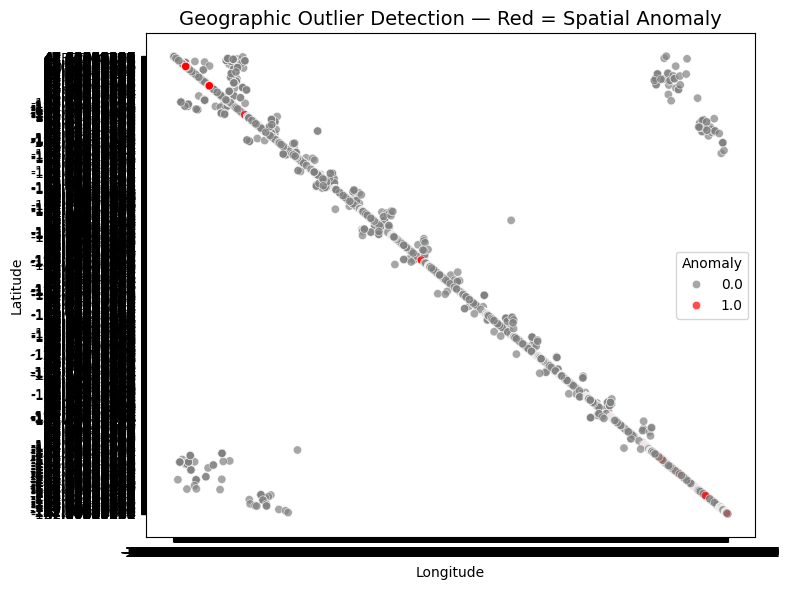

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#had to limit to vis in here
geo_pd = (
    df_geo
    .select(GROUP_COL, LAT_COL, LON_COL, "is_geo_anomaly")
    .dropna(subset=[LAT_COL, LON_COL])  
    .sample(fraction=0.1, seed=42)     
    .limit(10000)                       
    .toPandas()
)


plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=geo_pd,
    x=LON_COL, y=LAT_COL,
    hue="is_geo_anomaly",
    palette={0: "gray", 1: "red"},
    alpha=0.7
)
plt.title("Geographic Outlier Detection — Red = Spatial Anomaly", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Anomaly")
plt.tight_layout()
plt.show()


Most call locations fall along one clear geographic line, showing that incidents are concentrated in a consistent service area. Only a few points are flagged as spatial anomalies, and they sit just outside that main corridor. These likely come from minor coordinate errors or calls happening near boundary edges rather than true location mistakes. Overall, the data shows strong geographic consistency with only a few scattered outliers.

### Temporal Burst Detection

Detect sudden surges in call volume in a neighborhood or beat (possible real-world incidents).

Apply moving-window statistics or a Poisson-based anomaly model on counts per time interval

In [20]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window


df_spark = df_spark.withColumn("event_hour", F.date_trunc("hour", F.col("event_time")))

hourly_counts = (df_spark.groupBy("event_hour").agg(F.count("*").alias("total_calls")).orderBy("event_hour"))
hourly_counts.show(10, truncate=False)


+-------------------+-----------+
|event_hour         |total_calls|
+-------------------+-----------+
|2023-10-27 00:00:00|29         |
|2023-10-27 01:00:00|26         |
|2023-10-27 02:00:00|13         |
|2023-10-27 03:00:00|13         |
|2023-10-27 04:00:00|18         |
|2023-10-27 05:00:00|24         |
|2023-10-27 06:00:00|24         |
|2023-10-27 07:00:00|38         |
|2023-10-27 08:00:00|45         |
|2023-10-27 09:00:00|45         |
+-------------------+-----------+
only showing top 10 rows



In [21]:
w = Window.orderBy("event_hour").rowsBetween(-6, 6)

hourly_counts = (hourly_counts.withColumn("rolling_mean", F.avg("total_calls").over(w)).withColumn("rolling_std", F.stddev("total_calls").over(w)))
hourly_counts = hourly_counts.withColumn("z_score",(F.col("total_calls") - F.col("rolling_mean")) / (F.col("rolling_std") + F.lit(1e-6)))
hourly_counts = hourly_counts.withColumn("is_burst", (F.col("z_score") > 2.5).cast("int"))
hourly_counts.select("event_hour", "total_calls", "rolling_mean", "z_score", "is_burst").show(10, truncate=False)


25/10/26 18:12:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:12:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:12:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:12:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:12:02 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:12:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 1

+-------------------+-----------+------------------+-------------------+--------+
|event_hour         |total_calls|rolling_mean      |z_score            |is_burst|
+-------------------+-----------+------------------+-------------------+--------+
|2023-10-27 00:00:00|29         |21.0              |1.2544998996530794 |0       |
|2023-10-27 01:00:00|26         |23.125            |0.3412426017332945 |0       |
|2023-10-27 02:00:00|13         |25.555555555555557|-1.1694000164818894|0       |
|2023-10-27 03:00:00|13         |27.5              |-1.22425962446438  |0       |
|2023-10-27 04:00:00|18         |28.363636363636363|-0.8937671417291246|0       |
|2023-10-27 05:00:00|24         |29.75             |-0.4770257188723319|0       |
|2023-10-27 06:00:00|24         |31.76923076923077 |-0.5693733323616285|0       |
|2023-10-27 07:00:00|38         |33.15384615384615 |0.34029451965939156|0       |
|2023-10-27 08:00:00|45         |35.46153846153846 |0.6205470579307294 |0       |
|2023-10-27 09:0

25/10/26 18:12:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:12:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:12:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:12:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:12:04 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:12:05 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 1

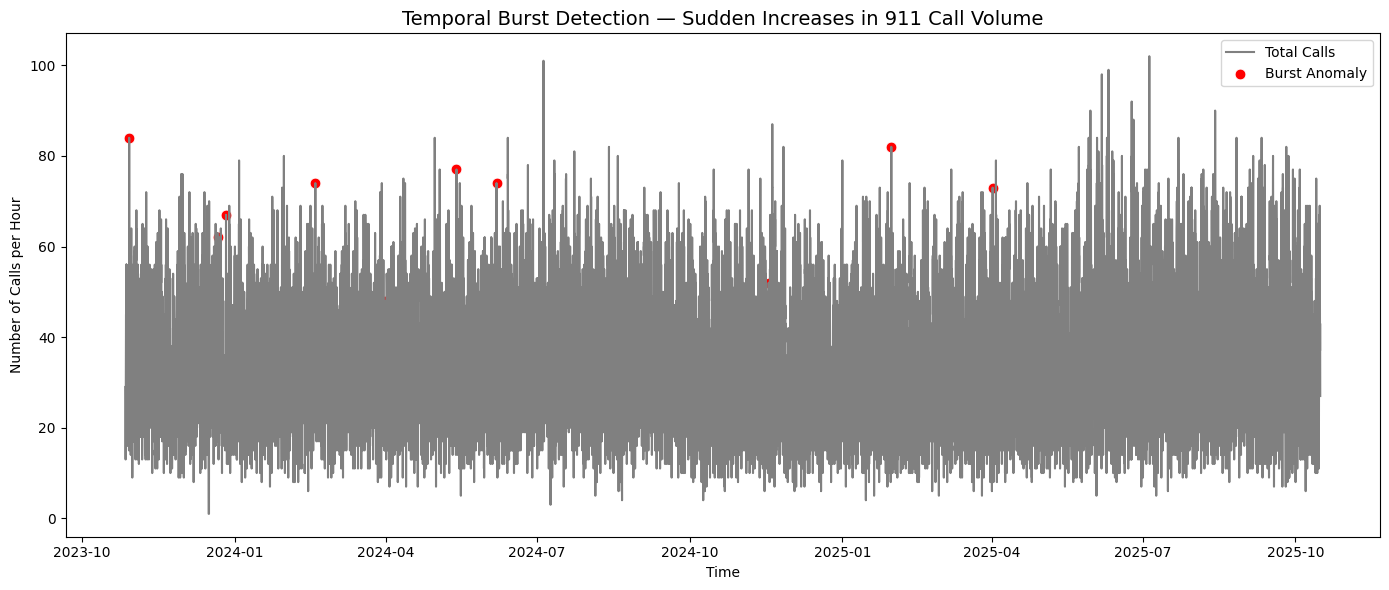

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

hourly_pd = hourly_counts.toPandas()

plt.figure(figsize=(14,6))
sns.lineplot(data=hourly_pd, x="event_hour", y="total_calls", label="Total Calls", color="gray")
sns.scatterplot(
    data=hourly_pd[hourly_pd["is_burst"] == 1],
    x="event_hour", y="total_calls",
    color="red", label="Burst Anomaly", s=60
)
plt.title("Temporal Burst Detection — Sudden Increases in 911 Call Volume", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Number of Calls per Hour")
plt.legend()
plt.tight_layout()
plt.show()


Now do it per dispatch_sector

In [23]:
sector_window = Window.partitionBy("dispatch_sector").orderBy("event_hour").rowsBetween(-6, 6)

sector_bursts = (df_spark
    .withColumn("event_hour", F.date_trunc("hour", F.col("event_time")))
    .groupBy("dispatch_sector", "event_hour")
    .agg(F.count("*").alias("total_calls"))
    .withColumn("rolling_mean", F.avg("total_calls").over(sector_window))
    .withColumn("rolling_std", F.stddev("total_calls").over(sector_window))
    .withColumn("z_score", (F.col("total_calls") - F.col("rolling_mean")) / (F.col("rolling_std") + F.lit(1e-6)))
    .withColumn("is_burst", (F.col("z_score") > 2.5).cast("int")))


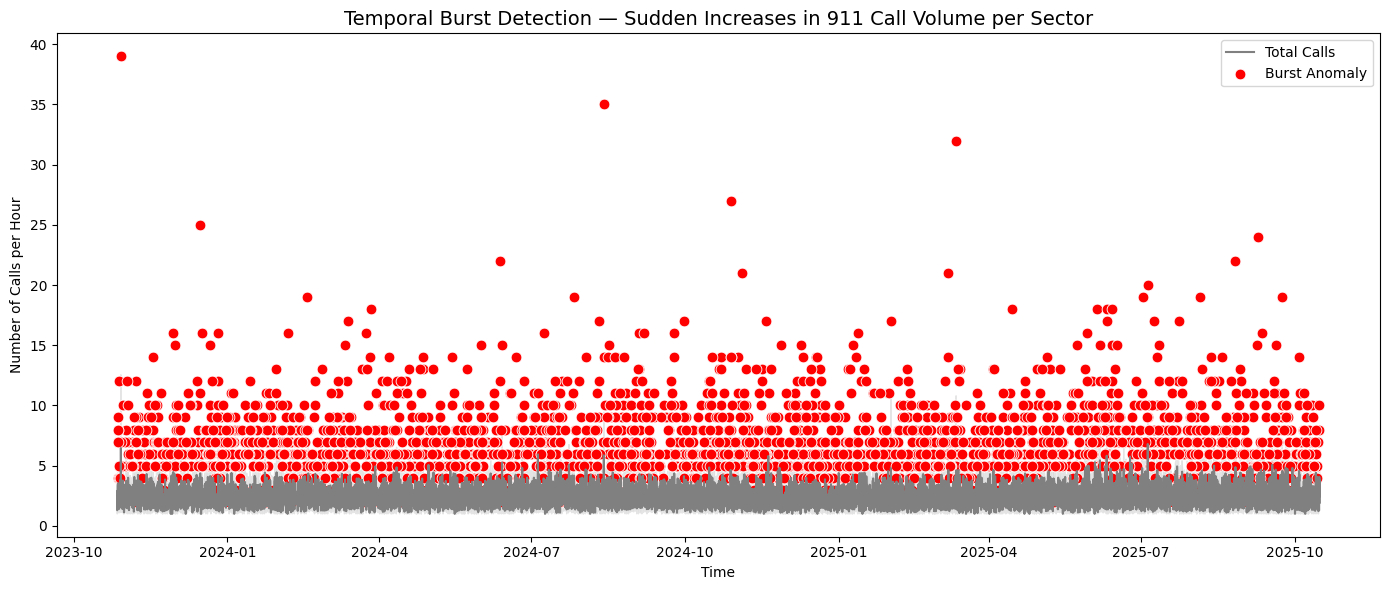

In [24]:
sector_bursts_pd = sector_bursts.toPandas()

plt.figure(figsize=(14,6))
sns.lineplot(data=sector_bursts_pd, x="event_hour", y="total_calls", label="Total Calls", color="gray")
sns.scatterplot(
    data=sector_bursts_pd[sector_bursts_pd["is_burst"] == 1],
    x="event_hour", y="total_calls",
    color="red", label="Burst Anomaly", s=60
)
plt.title("Temporal Burst Detection — Sudden Increases in 911 Call Volume per Sector", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Number of Calls per Hour")
plt.legend()
plt.tight_layout()
plt.show()

At the sector level, small bursts appear regularly, reflecting local fluctuations in activity. However, when aggregated across the entire city, only a handful of major spikes remain, indicating that most surges are localized rather than system-wide. Overall call patterns are steady, with a few short periods of exceptionally high volume that stand out as true temporal anomalies worth further review.

In [25]:
df_w_cad_hourly = (df_spark.select("cad_event_number", "event_hour") .join(hourly_counts, on="event_hour", how="left"))
df_w_cad_hourly.select("cad_event_number","event_hour","total_calls","rolling_mean","z_score","is_burst").show(10, truncate=False)

df_w_cad_sector = (df_spark.select("cad_event_number", "event_hour", "dispatch_sector").join(sector_bursts, on=["event_hour", "dispatch_sector"], how="left"))
df_w_cad_sector.select("cad_event_number","dispatch_sector","event_hour","total_calls","z_score","is_burst").show(10, truncate=False)

25/10/26 18:17:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:17:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:17:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:17:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:17:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:17:03 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 1

+----------------+-------------------+-----------+-----------------+----------------+--------+
|cad_event_number|event_hour         |total_calls|rolling_mean     |z_score         |is_burst|
+----------------+-------------------+-----------+-----------------+----------------+--------+
|2023000321296   |2023-11-06 09:00:00|52         |42.46153846153846|0.61365960384555|0       |
|2023000321297   |2023-11-06 09:00:00|52         |42.46153846153846|0.61365960384555|0       |
|2023000321298   |2023-11-06 09:00:00|52         |42.46153846153846|0.61365960384555|0       |
|2023000321299   |2023-11-06 09:00:00|52         |42.46153846153846|0.61365960384555|0       |
|2023000321300   |2023-11-06 09:00:00|52         |42.46153846153846|0.61365960384555|0       |
|2023000321301   |2023-11-06 09:00:00|52         |42.46153846153846|0.61365960384555|0       |
|2023000321302   |2023-11-06 09:00:00|52         |42.46153846153846|0.61365960384555|0       |
|2023000321303   |2023-11-06 09:00:00|52         |

+----------------+---------------+-------------------+-----------+-------------------+--------+
|cad_event_number|dispatch_sector|event_hour         |total_calls|z_score            |is_burst|
+----------------+---------------+-------------------+-----------+-------------------+--------+
|2024000028856   |EDWARD         |2024-01-31 09:00:00|2          |-0.499999750000125 |0       |
|2024000028860   |OCEAN          |2024-01-31 09:00:00|6          |0.9975132157870713 |0       |
|2024000028861   |SAM            |2024-01-31 09:00:00|4          |0.6344320528197028 |0       |
|2024000028864   |SAM            |2024-01-31 09:00:00|4          |0.6344320528197028 |0       |
|2024000119761   |DAVID          |2024-05-03 03:00:00|2          |-0.7071062811869011|0       |
|2024000119762   |WILLIAM        |2024-05-03 03:00:00|1          |-0.9460991063103641|0       |
|2024000119767   |EDWARD         |2024-05-03 04:00:00|2          |-0.8660246537850881|0       |
|2024000211053   |JOHN           |2024-0

### Dispatch Routing Anomalies

Detect when a call is assigned to a precinct or sector far from the incident location.

Compute distance between call location and assigned dispatch sector centroid.

In [26]:
from pyspark.sql import functions as F

def haversine_distance(lat1, lon1, lat2, lon2):
    return (F.lit(6371) * 2 * F.asin(
            F.sqrt(F.pow(F.sin((F.radians(lat2 - lat1)) / 2), 2) + F.cos(F.radians(lat1)) * F.cos(F.radians(lat2)) * F.pow(F.sin((F.radians(lon2 - lon1)) / 2), 2))))


In [27]:
# Group by dispatch sector (or use 'dispatch_beat' or 'dispatch_precinct')
sector_centroids = (df_spark.groupBy("dispatch_sector")
    .agg(F.avg("dispatch_latitude").alias("sector_lat"), F.avg("dispatch_longitude").alias("sector_lon"), F.count("*").alias("n_calls")))


In [ ]:
df_dist = df_spark.join(sector_centroids, on="dispatch_sector", how="left")

df_dist = df_dist.withColumn("distance_km",
    haversine_distance( F.col("dispatch_latitude"), F.col("dispatch_longitude"), F.col("sector_lat"), F.col("sector_lon")))


In [ ]:
from pyspark.sql.window import Window

w = Window.partitionBy("dispatch_sector")

df_dist = (df_dist
    .withColumn("mean_dist", F.avg("distance_km").over(w))
    .withColumn("std_dist", F.stddev("distance_km").over(w))
    .withColumn("z_score", (F.col("distance_km") - F.col("mean_dist")) / (F.col("std_dist") + F.lit(1e-6)))
    .withColumn("is_routing_anomaly", (F.col("z_score") > 3).cast("int")))

df_dist.select("dispatch_sector", "dispatch_latitude", "dispatch_longitude", "distance_km", "z_score", "is_routing_anomaly").show(10, truncate=False)

+---------------+-----------------+------------------+-----------------+--------------------+------------------+
|dispatch_sector|dispatch_latitude|dispatch_longitude|distance_km      |z_score             |is_routing_anomaly|
+---------------+-----------------+------------------+-----------------+--------------------+------------------+
|EDWARD         |47.62049181      |-122.32088228     |699.8516022693801|-0.18641439876778038|0                 |
|EDWARD         |47.61584806      |-122.31686351     |699.2614859774161|-0.1867195456807483 |0                 |
|EDWARD         |47.61642730      |-122.31752556     |699.3427523884183|-0.18667752312556218|0                 |
|EDWARD         |47.61811629      |-122.32674640     |699.9271071269305|-0.18637535549019366|0                 |
|EDWARD         |47.61757129      |-122.32083583     |699.5986547032314|-0.18654519700196595|0                 |
|EDWARD         |47.62255409      |-122.31991546     |699.9826644387063|-0.18634662701343066|0  

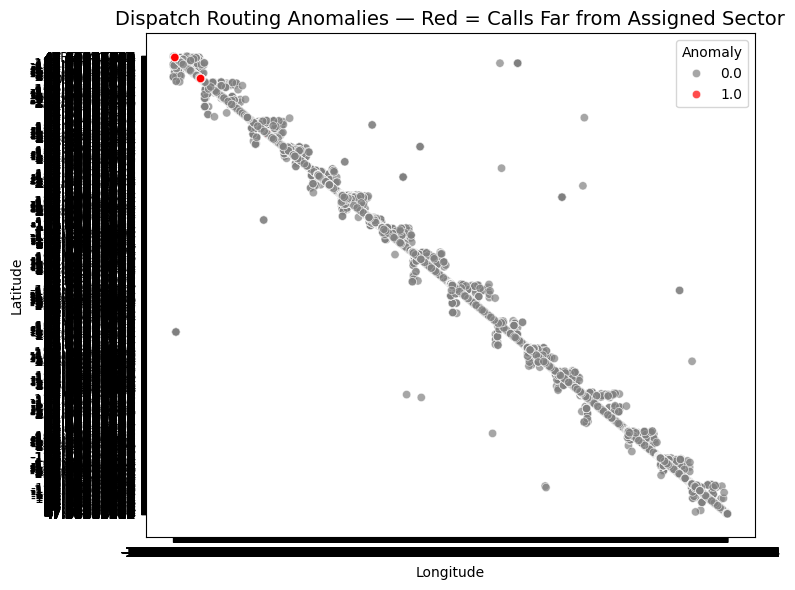

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

routing_pd = (df_dist.select("dispatch_latitude", "dispatch_longitude", "is_routing_anomaly").dropna(subset=["dispatch_latitude", "dispatch_longitude"])
                     .sample(fraction=0.05, seed=42).toPandas())

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=routing_pd,
    x="dispatch_longitude", y="dispatch_latitude",
    hue="is_routing_anomaly",
    palette={0: "gray", 1: "red"},
    alpha=0.7
)
plt.title("Dispatch Routing Anomalies — Red = Calls Far from Assigned Sector", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Anomaly")
plt.tight_layout()
plt.show()


Most calls were routed correctly and fall within expected geographic areas for their sectors. Only a couple of points were flagged as anomalies, sitting at the outer edges of the coverage zone. These few cases likely represent minor boundary overlaps or data entry errors rather than true routing problems, showing overall strong dispatch accuracy.

### Summarize / Putting all results together

In [31]:
print("Response Time Anomalies DF")
hourly_calls_w_cad.show(5)
print("Call Type Mismatch Anomalies DF")
transition_w_cad.show(5)
print("Georgraphic Outlier Detection DF")
df_geo.show(5)
print("Temporal Burst Detection DF")
df_w_cad_hourly.show(5)
print("per sector")
df_w_cad_sector.show(5)
print("Dispatch Routing Anomalies")
df_dist.show(5)

Response Time Anomalies DF


+----------+----+--------------------+----------------+------------------------------+-----------+------------------+-----------------+-----------------+------------------+----------+
|      date|hour|           call_type|cad_event_number|call_sign_total_service_time_s|total_calls|  avg_service_time|       mean_calls|        std_calls|           z_score|is_anomaly|
+----------+----+--------------------+----------------+------------------------------+-----------+------------------+-----------------+-----------------+------------------+----------+
|2023-11-06|   9|TELEPHONE OTHER N...|   2023000321297|                          2982|         13| 5194.692307692308| 8.34330283837673|4.837105527919149|0.9627030404944404|         0|
|2023-11-06|   9|TELEPHONE OTHER N...|   2023000321301|                          1770|         13| 5194.692307692308| 8.34330283837673|4.837105527919149|0.9627030404944404|         0|
|2023-11-06|   9|                 911|   2023000321296|                         

+-------------------------+-----------------------+----------------+-----+--------------------+----------+------------------+
|initial_call_type_mapping|final_call_type_mapping|cad_event_number|count|                 pct|is_anomaly|is_self_transition|
+-------------------------+-----------------------+----------------+-----+--------------------+----------+------------------+
|                     AUTO|                   AUTO|   2023000321300|18031|0.028089870136344376|         0|                 1|
|                     AUTO|                   AUTO|   2023000321301|18031|0.028089870136344376|         0|                 1|
|                      TRU|                   BURG|   2023000321297| 2983|0.004647112340786...|         1|                 0|
|                      OBS|    DISTURBANCE - OTHER|   2023000321298|  770|0.001199556319948...|         1|                 0|
|     DISTURBANCE - DV ...|             SUSPICIOUS|   2023000321296|   92|1.433236122535457E-4|         1|            

+---------------+----------------+-------------------------------+--------------------+--------+--------------------+----------------------------------+-------------------------+--------------------+-----------------------+------------------------------+-----------------------------------+-----------------------------------+---------------------------------------+--------------------------------------------+-------------------------------+-----------------+-------------+------------------+-----------------+-----------------------+---------------------------+---------------------+--------------------------------+-------------------------------------------+-------------------------------------------+--------------------------------------------------+--------------------------------------------------+------------------------------------------+------------------------------------------+--------------------------------------------+---------------------------------------------------+--------

25/10/26 18:25:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:25:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:25:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:25:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:25:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:25:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 1

+-------------------+----------------+-----------+-----------------+------------------+----------------+--------+
|         event_hour|cad_event_number|total_calls|     rolling_mean|       rolling_std|         z_score|is_burst|
+-------------------+----------------+-----------+-----------------+------------------+----------------+--------+
|2023-11-06 09:00:00|   2023000321296|         52|42.46153846153846|15.543569863534055|0.61365960384555|       0|
|2023-11-06 09:00:00|   2023000321297|         52|42.46153846153846|15.543569863534055|0.61365960384555|       0|
|2023-11-06 09:00:00|   2023000321298|         52|42.46153846153846|15.543569863534055|0.61365960384555|       0|
|2023-11-06 09:00:00|   2023000321299|         52|42.46153846153846|15.543569863534055|0.61365960384555|       0|
|2023-11-06 09:00:00|   2023000321300|         52|42.46153846153846|15.543569863534055|0.61365960384555|       0|
+-------------------+----------------+-----------+-----------------+------------------+-

+-------------------+---------------+----------------+-----------+------------------+------------------+-------------------+--------+
|         event_hour|dispatch_sector|cad_event_number|total_calls|      rolling_mean|       rolling_std|            z_score|is_burst|
+-------------------+---------------+----------------+-----------+------------------+------------------+-------------------+--------+
|2024-01-31 09:00:00|         EDWARD|   2024000028856|          2|               3.0|               2.0| -0.499999750000125|       0|
|2024-01-31 09:00:00|          OCEAN|   2024000028860|          6|3.1538461538461537| 2.853248261372578| 0.9975132157870713|       0|
|2024-01-31 09:00:00|            SAM|   2024000028861|          4|2.8461538461538463|1.8187062180825984| 0.6344320528197028|       0|
|2024-05-03 03:00:00|          DAVID|   2024000119761|          2|               3.0|1.4142135623730951|-0.7071062811869011|       0|
|2024-05-03 03:00:00|        WILLIAM|   2024000119762|        

+---------------+----------------+-------------------------------+--------------------+--------+--------------------+----------------------------------+-------------------------+--------------------+-----------------------+------------------------------+-----------------------------------+-----------------------------------+---------------------------------------+--------------------------------------------+-------------------------------+-----------------+-------------+------------------+-----------------+-----------------------+---------------------------+---------------------+--------------------------------+-------------------------------------------+-------------------------------------------+--------------------------------------------------+--------------------------------------------------+------------------------------------------+------------------------------------------+--------------------------------------------+---------------------------------------------------+--------

In [33]:
from pyspark.sql import functions as F

df_response = hourly_calls_w_cad.select("cad_event_number", "is_anomaly")
df_geo_flag = df_geo.select("cad_event_number", "is_geo_anomaly")
df_routing = df_dist.select("cad_event_number", "is_routing_anomaly")
df_burst = df_w_cad_hourly.select("cad_event_number", "is_burst") 
df_type = transition_w_cad.select("cad_event_number", "is_anomaly").withColumnRenamed("is_anomaly", "is_type_anomaly")

df_response = df_response.withColumnRenamed("is_anomaly", "is_response_anomaly")
df_burst = df_burst.withColumnRenamed("is_burst", "is_burst_anomaly")

df_final_anomaly_detection = (
    df_spark
    .select("cad_event_number", "dispatch_sector", "call_type", "event_time")
    .join(df_response, on="cad_event_number", how="left")
    .join(df_burst, on="cad_event_number", how="left")
    .join(df_type, on="cad_event_number", how="left")
    .join(df_geo_flag, on="cad_event_number", how="left")
    .join(df_routing, on="cad_event_number", how="left")
)

df_final_anomaly_detection = df_final_anomaly_detection.withColumn(
    "is_any_anomaly",
    (
        F.col("is_response_anomaly") +
        F.col("is_burst_anomaly") +
        F.col("is_type_anomaly") +
        F.col("is_geo_anomaly") +
        F.col("is_routing_anomaly")
    ).cast("int")
)


df_final_anomaly_detection.select(
    "cad_event_number",
    "is_response_anomaly",
    "is_burst_anomaly",
    "is_type_anomaly",
    "is_geo_anomaly",
    "is_routing_anomaly",
    "is_any_anomaly"
).show(10, truncate=False)


25/10/26 18:37:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:37:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:37:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:37:57 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:37:59 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 18:37:59 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/10/26 1

+----------------+-------------------+----------------+---------------+--------------+------------------+--------------+
|cad_event_number|is_response_anomaly|is_burst_anomaly|is_type_anomaly|is_geo_anomaly|is_routing_anomaly|is_any_anomaly|
+----------------+-------------------+----------------+---------------+--------------+------------------+--------------+
|2023000321297   |0                  |0               |1              |0             |0                 |1             |
|2023000321299   |0                  |0               |1              |0             |0                 |1             |
|2023000321301   |0                  |0               |0              |0             |0                 |0             |
|2024000119762   |0                  |0               |1              |0             |0                 |1             |
|2024000119763   |0                  |0               |1              |0             |0                 |1             |
|2024000119765   |0             

is_response_anomaly → Flags calls that occurred during hours where response times or call volumes were unusually high or low compared to typical patterns for that call type.

is_burst_anomaly → Marks time periods where there was a sudden short-term spike in total 911 call volume — a temporal “burst” indicating potential system overload or major incidents.

is_type_anomaly → Indicates calls where the initial classification of the incident didn’t match the final call type, highlighting possible mislabeling or reclassification during dispatch.

is_geo_anomaly → Flags calls whose location coordinates are unusually far from where similar calls or that dispatch sector typically occur — potential geographic outliers or coordinate errors.

is_routing_anomaly → Identifies calls that were dispatched to a sector or unit far from the incident’s actual location, suggesting routing mismatches or boundary assignment issues.

is_any_anomaly → A combined indicator showing whether a call was flagged by any of the five anomaly detection methods above (1 = at least one anomaly detected).